# Boosting 集成学习对比实验

## 实验目标
对比以下四种 Boosting 集成学习算法的**准确率**与**计算效率**：

| 算法 | 全称 | 特点 |
|------|------|------|
| AdaBoost | Adaptive Boosting | 通过调整样本权重迭代训练弱分类器 |
| GBDT | Gradient Boosting Decision Tree | 以梯度下降方式拟合残差 |
| XGBoost | eXtreme Gradient Boosting | GBDT 的高效工程实现，支持正则化 |
| LightGBM | Light Gradient Boosting Machine | 微软出品，基于直方图算法，速度更快 |

## 数据集
使用 sklearn 内置的 **乳腺癌数据集（Breast Cancer Wisconsin）**：
- 569 个样本，30 个特征
- 二分类任务：恶性（0）/ 良性（1）

## 1. 导入库

In [1]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 设置中文字体
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

所有库导入成功 ✓


## 2. 加载与探索数据集

In [2]:
# 加载数据集
data = load_breast_cancer()
X, y = data.data, data.target

# 转为 DataFrame 方便查看
df = pd.DataFrame(X, columns=data.feature_names)
df['label'] = y

print('数据集形状：', X.shape)
print('特征数量：', X.shape[1])
print('样本数量：', X.shape[0])
print('\n标签分布：')
print(pd.Series(y).value_counts().rename({0: '恶性(0)', 1: '良性(1)'})
      .to_frame('数量'))
df.head()

数据集形状： (569, 30)
特征数量： 30
样本数量： 569

标签分布：
        数量
良性(1)  357
恶性(0)  212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. 数据预处理

In [3]:
# 划分训练集和测试集（8:2）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 标准化（AdaBoost/GBDT 对尺度不敏感，但统一处理更公平）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'训练集：{X_train.shape[0]} 条')
print(f'测试集：{X_test.shape[0]} 条')

训练集：455 条
测试集：114 条


## 4. 定义模型

In [4]:
models = {
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),
    'GBDT': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbose=-1
    )
}

print('模型定义完成，参数对齐（n_estimators=100, learning_rate=0.1, max_depth=3）')

模型定义完成，参数对齐（n_estimators=100, learning_rate=0.1, max_depth=3）


## 5. 训练与测试（记录耗时）

In [5]:
results = []

for name, model in models.items():
    # --- 训练 ---
    t0 = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    train_time = time.perf_counter() - t0

    # --- 预测 ---
    t1 = time.perf_counter()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.perf_counter() - t1

    # --- 评估 ---
    acc = accuracy_score(y_test, y_pred)

    results.append({
        '模型': name,
        '准确率': round(acc, 4),
        '训练耗时(s)': round(train_time, 4),
        '预测耗时(s)': round(pred_time, 6)
    })

    print(f'[{name:10s}]  准确率: {acc:.4f}  训练: {train_time:.4f}s  预测: {pred_time:.6f}s')

results_df = pd.DataFrame(results).set_index('模型')


D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[AdaBoost  ]  准确率: 0.9561  训练: 0.1938s  预测: 0.005710s


[GBDT      ]  准确率: 0.9561  训练: 0.3282s  预测: 0.000377s
[XGBoost   ]  准确率: 0.9474  训练: 0.1744s  预测: 0.001095s


[LightGBM  ]  准确率: 0.9737  训练: 0.0620s  预测: 0.001216s

汇总表：


D:\conda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\conda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\conda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\conda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\conda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,准确率,训练耗时(s),预测耗时(s)
模型,,,
AdaBoost,0.9561,0.1938,0.005710
GBDT,0.9561,0.3282,0.000377
XGBoost,0.9474,0.1744,0.001095
LightGBM,0.9737,0.0620,0.001216


## 6. 详细分类报告

In [6]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f'\n======== {name} ========')
    print(classification_report(y_test, y_pred, target_names=['恶性', '良性']))


======== AdaBoost ========
              precision    recall  f1-score   support

          恶性       0.97      0.90      0.94        42
          良性       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


======== GBDT ========
              precision    recall  f1-score   support

          恶性       0.97      0.90      0.94        42
          良性       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


======== XGBoost ========
              precision    recall  f1-score   support

          恶性       0.95      0.90      0.93        42
          良性       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94      

## 7. 5折交叉验证

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv_results = {}

for name, model in models.items():
    # 包在 Pipeline 中确保每折都进行标准化
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:10s}  均值: {scores.mean():.4f}  标准差: {scores.std():.4f}  各折: {np.round(scores, 4)}')

D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
D:\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost    均值: 0.9613  标准差: 0.0119  各折: [0.9474 0.9561 0.9825 0.9561 0.9646]


GBDT        均值: 0.9631  标准差: 0.0210  各折: [0.9298 0.9474 0.9737 0.9825 0.9823]
XGBoost     均值: 0.9684  标准差: 0.0163  各折: [0.9561 0.9474 0.9912 0.9825 0.9646]


LightGBM    均值: 0.9666  标准差: 0.0217  各折: [0.9298 0.9561 0.9912 0.9737 0.9823]


## 8. 可视化对比

C:\Users\liuwenbo\AppData\Local\Temp\ipykernel_34328\4164523926.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cv_data, labels=names, patch_artist=True,


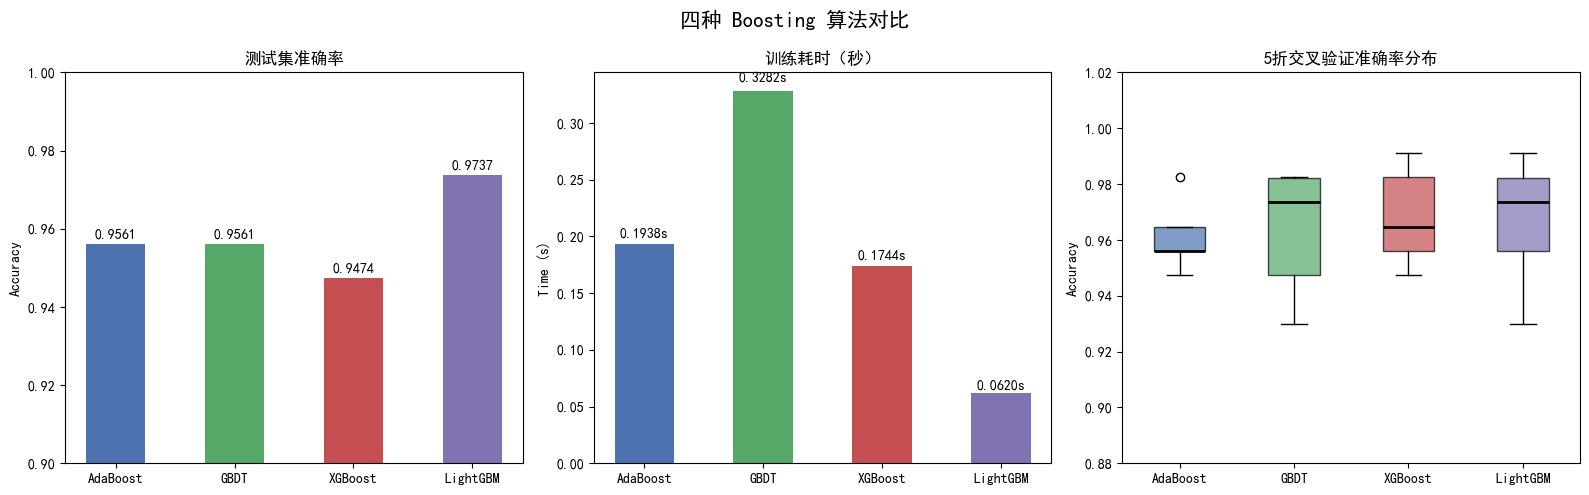

图表已保存为 boosting_comparison.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('四种 Boosting 算法对比', fontsize=15, fontweight='bold')

names   = results_df.index.tolist()
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# ---- 图1：准确率 ----
ax = axes[0]
bars = ax.bar(names, results_df['准确率'], color=colors, width=0.5)
ax.set_ylim(0.9, 1.0)
ax.set_title('测试集准确率')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, results_df['准确率']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# ---- 图2：训练耗时 ----
ax = axes[1]
bars = ax.bar(names, results_df['训练耗时(s)'], color=colors, width=0.5)
ax.set_title('训练耗时（秒）')
ax.set_ylabel('Time (s)')
for bar, val in zip(bars, results_df['训练耗时(s)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=10)

# ---- 图3：5折交叉验证箱线图 ----
ax = axes[2]
cv_data = [cv_results[n] for n in names]
bp = ax.boxplot(cv_data, labels=names, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('5折交叉验证准确率分布')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.88, 1.02)

plt.tight_layout()
plt.savefig('boosting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存为 boosting_comparison.png')